Importing necessary packages.

In [3]:
import matplotlib.pyplot as plt  #To plot transform results
import os                        #To load images from local directory
from scipy import signal         #To use convolve2d for convolution of wavelet filters onto images
import numpy as np               #To use mathematical operations & array operations
from PIL import Image            #To load images from local directory 
import pywt                      #Packages implementing wavelet transform, used to compare performance of self-implemented wavelet transform
import math                      

Implementing wavelet transform & denoising.

In [4]:
class Wavelet:
    def upSample(self, img, n):
        result = np.zeros((img.shape[0] * n, img.shape[1] * n))
        result[::n,::n] = img
        return result
    
    def DWT2D(self, img, levels):
        s = signal.convolve2d(img, self.Hbar, mode = "valid")[::2, ::2]
        w1 = signal.convolve2d(img, self.G1bar, mode = "valid")[::2, ::2]
        w2 = signal.convolve2d(img, self.G2bar, mode = "valid")[::2, ::2]
        w3 = signal.convolve2d(img, self.G3bar, mode = "valid")[::2, ::2]
        if levels > 1:
            result = self.DWT2D(s, levels - 1)
        else: result = s
        return (result, w1, w2, w3)

    def iDWT2D(self, coefficients, levels):
        s, w1, w2, w3 = coefficients
        if levels > 1:
            s = self.iDWT2D(s, levels - 1)         
        s = signal.convolve2d(self.upSample(s, 2), self.H, mode = "same")[:,:]
        w1 = signal.convolve2d(self.upSample(w1, 2), self.G1, mode = "same")[:, :]
        w2 = signal.convolve2d(self.upSample(w2, 2), self.G2, mode = "same")[:, :]
        w3 = signal.convolve2d(self.upSample(w3, 2), self.G3, mode = "same")[:, :]
        return s + w1 + w2 + w3

    @staticmethod
    def hard_thresholding(img, threshold):
        img[np.abs(img) <= threshold] = 0
        return img

    @staticmethod
    def soft_thresholding(img, threshold):
        return np.sign(img) * np.maximum(np.abs(img) - threshold, 0)

    def denoising(self, img, threshold, mode, levels):
        s, w1, w2, w3 = self.DWT2D(img, 1)
        if levels > 1:
            s = self.denoising(s, threshold, mode, levels - 1)
        if (mode == 'hard'):
            return self.iDWT2D((s,
                          self.hard_thresholding(w1, threshold),
                          self.hard_thresholding(w2, threshold),
                          self.hard_thresholding(w3, threshold)), 1)
        elif(mode == 'soft'):
            return self.iDWT2D((s,
                          self.soft_thresholding(w1, threshold),
                          self.soft_thresholding(w2, threshold),
                          self.soft_thresholding(w3, threshold)), 1)

In [5]:
class Haar(Wavelet):
    def __init__(self):
        self.h = np.multiply(1 / np.sqrt(2), np.array([1, 1]))
        self.g = np.multiply(1 / np.sqrt(2), np.array([-1, 1]))
        self.H = np.tensordot(self.h, self.h, axes = 0)
        self.G1 = np.tensordot(self.h, self.g, axes = 0)
        self.G2 = np.tensordot(self.g, self.h, axes = 0)
        self.G3 = np.tensordot(self.g, self.g, axes = 0)
        
        self.Hbar = np.flip(self.H)
        self.G1bar = np.flip(self.G1)
        self.G2bar = np.flip(self.G2)
        self.G3bar = np.flip(self.G3)

In [6]:
class Db4(Wavelet):
    def __init__(self):
        self.h = [-0.0105974017850021, 0.032883011666982945, 0.030841381835560763, -0.18703481171888114, 
                  -0.02798376941698385, 0.6308807679295904, 0.7148465705529154, 0.23037781330885523]
        self.g = [0.23037781330885523, -0.7148465705529154, 0.6308807679295904, 0.02798376941698385,
                  -0.18703481171888114, -0.030841381835560763, 0.032883011666982945, 0.0105974017850021]
        
        self.H = np.tensordot(self.h, self.h, axes = 0)
        self.G1 = np.tensordot(self.h, self.g, axes = 0)
        self.G2 = np.tensordot(self.g, self.h, axes = 0)
        self.G3 = np.tensordot(self.g, self.g, axes = 0)
        
        self.Hbar = np.flip(self.H)
        self.G1bar = np.flip(self.G1)
        self.G2bar = np.flip(self.G2)
        self.G3bar = np.flip(self.G3)

    @staticmethod
    def pad_with_edge(arr, pad_width):
        return np.pad(arr, pad_width=((pad_width, pad_width), (pad_width, pad_width)), mode='edge')
    
    def DWT2D(self, img, levels):
        start = 4
        endv = 4 + img.shape[0]
        endh = 4 + img.shape[1]
        s = signal.convolve2d(img, self.Hbar, mode = "full", boundary = 'symm')[start:endv:2, start:endh:2]
        w1 = signal.convolve2d(img, self.G1bar, mode = "full", boundary = 'symm')[start:endv:2, start:endh:2]
        w2 = signal.convolve2d(img, self.G2bar, mode = "full", boundary = 'symm')[start:endv:2, start:endh:2]
        w3 = signal.convolve2d(img, self.G3bar, mode = "full", boundary = 'symm')[start:endv:2, start:endh:2]
        if levels > 1:
            result = self.DWT2D(s, levels - 1)
        else: result = s
        return (result, w1, w2, w3)

    def iDWT2D(self, coefficients, levels):
        s, w1, w2, w3 = coefficients
        start = 0
        endv = w1.shape[0] * 2
        endh = w1.shape[1] * 2
        if levels > 1:
            s = self.iDWT2D(s, levels - 1)      
        s = self.pad_with_edge(s, 2)
        w1 = self.pad_with_edge(w1, 2)
        w2 = self.pad_with_edge(w2, 2)
        w3 = self.pad_with_edge(w3, 2)
        s = signal.convolve2d(self.upSample(s, 2), self.H, mode = "valid", boundary = 'symm')[start:endv,start:endh]
        w1 = signal.convolve2d(self.upSample(w1, 2), self.G1, mode = "valid", boundary = 'symm')[start:endv,start:endh]
        w2 = signal.convolve2d(self.upSample(w2, 2), self.G2, mode = "valid", boundary = 'symm')[start:endv,start:endh]
        w3 = signal.convolve2d(self.upSample(w3, 2), self.G3, mode = "valid", boundary = 'symm')[start:endv,start:endh]
        return s + w1 + w2 + w3

In [7]:
class Db4(Wavelet):
    def __init__(self):
        self.h = [-0.0105974017850021, 0.032883011666982945, 0.030841381835560763, -0.18703481171888114, 
                  -0.02798376941698385, 0.6308807679295904, 0.7148465705529154, 0.23037781330885523]
        self.g = [0.23037781330885523, -0.7148465705529154, 0.6308807679295904, 0.02798376941698385,
                  -0.18703481171888114, -0.030841381835560763, 0.032883011666982945, 0.0105974017850021]
        
        self.H = np.tensordot(self.h, self.h, axes = 0)
        self.G1 = np.tensordot(self.h, self.g, axes = 0)
        self.G2 = np.tensordot(self.g, self.h, axes = 0)
        self.G3 = np.tensordot(self.g, self.g, axes = 0)
        
        self.Hbar = np.flip(self.H)
        self.G1bar = np.flip(self.G1)
        self.G2bar = np.flip(self.G2)
        self.G3bar = np.flip(self.G3)

    @staticmethod
    def pad_with_edge(arr, pad_width):
        return np.pad(arr, pad_width=((pad_width, pad_width), (pad_width, pad_width)), mode='edge')
    
    def DWT2D(self, img, levels):
        start = 4
        endv = 4 + img.shape[0]
        endh = 4 + img.shape[1]
        s = signal.convolve2d(img, self.Hbar, mode = "full", boundary = 'wrap')[start:endv:2, start:endh:2]
        w1 = signal.convolve2d(img, self.G1bar, mode = "full", boundary = 'wrap')[start:endv:2, start:endh:2]
        w2 = signal.convolve2d(img, self.G2bar, mode = "full", boundary = 'wrap')[start:endv:2, start:endh:2]
        w3 = signal.convolve2d(img, self.G3bar, mode = "full", boundary = 'wrap')[start:endv:2, start:endh:2]
        if levels > 1:
            result = self.DWT2D(s, levels - 1)
        else: result = s
        return (result, w1, w2, w3)

    def iDWT2D(self, coefficients, levels):
        s, w1, w2, w3 = coefficients
        start = 0
        endv = w1.shape[0] * 2
        endh = w1.shape[1] * 2
        if levels > 1:
            s = self.iDWT2D(s, levels - 1)      
        s = signal.convolve2d(self.upSample(s, 2), self.H, mode = "same", boundary = 'wrap')[start:endv,start:endh]
        w1 = signal.convolve2d(self.upSample(w1, 2), self.G1, mode = "same", boundary = 'wrap')[start:endv,start:endh]
        w2 = signal.convolve2d(self.upSample(w2, 2), self.G2, mode = "same", boundary = 'wrap')[start:endv,start:endh]
        w3 = signal.convolve2d(self.upSample(w3, 2), self.G3, mode = "same", boundary = 'wrap')[start:endv,start:endh]
        return s + w1 + w2 + w3

Defining helper functions.

In [8]:
def normalize(img):
    return (img - np.min(img)) / (np.max(img) - np.min(img))

def gaussian_noise(img, sigma):
    temp = np.copy(img).astype(float)
    temp += np.random.normal(0, sigma, np.shape(temp))
    return temp

def blur(img, kernel):
    temp = np.copy(img)
    return signal.convolve(temp, kernel, "same")

def MSE(original, current):
    return np.square(current - original).mean()

def PSNR(orginal, current):
    max = np.max(orginal)
    return 20 * math.log10(max) - 10 * math.log10(MSE(orginal, current))



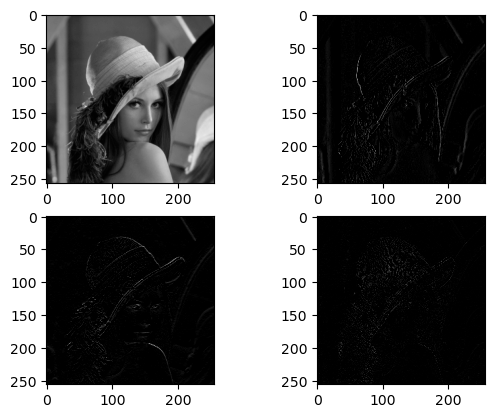

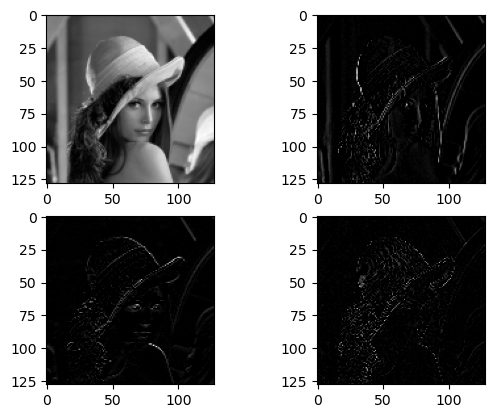

In [12]:
a = Haar()
img = normalize(np.asarray(Image.open('./lena512.jpg').convert('L')))
coeff = pywt.dwt2(img, 'haar')
CA,(c,d,e) = coeff
s,w1,w2,w3 = a.DWT2D(img, 1)
plt.subplot(2,2,1)
plt.imshow(s, cmap='gray', vmin=0, vmax=np.max(s))
plt.subplot(2,2,2)
plt.imshow(w1, cmap='gray', vmin=0, vmax=np.max(w1))
plt.subplot(2,2,3)
plt.imshow(w2, cmap='gray', vmin=0, vmax=np.max(w2))
plt.subplot(2,2,4)
plt.imshow(w3, cmap='gray', vmin=0, vmax=np.max(w3))
plt.show()
mse = MSE(CA, s)

(s2, w21, w22, w23),w1,w2,w3 = a.DWT2D(img, 2)
coeff = pywt.dwt2(CA, 'haar')
CA,(c,d,e) = coeff
plt.subplot(2,2,1)
plt.imshow(s2, cmap='gray', vmin=0, vmax=np.max(s2))
plt.subplot(2,2,2)
plt.imshow(w21, cmap='gray', vmin=0, vmax=np.max(w21))
plt.subplot(2,2,3)
plt.imshow(w22, cmap='gray', vmin=0, vmax=np.max(w22))
plt.subplot(2,2,4)
plt.imshow(w23, cmap='gray', vmin=0, vmax=np.max(w23))
plt.show()
mse = MSE(CA, s2)

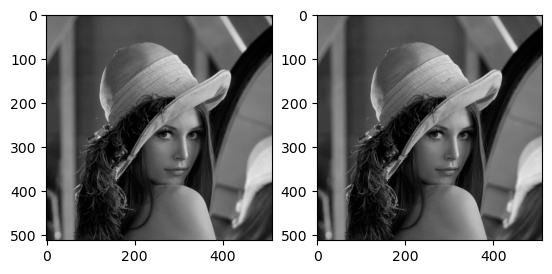

In [8]:
reconstructed = a.iDWT2D((s, w1, w2, w3), 1)
reconstructed = reconstructed

plt.subplot(1,2,1)
plt.imshow(reconstructed, cmap='gray', vmin=0, vmax=1)
plt.subplot(1,2,2)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.show()

In [9]:
print(f"MSE of reconstructed image compared to original image: {MSE(img, reconstructed)}")
print(f"PSNR of reconstructed image compared to original image: {PSNR(img, reconstructed)}")

MSE of reconstructed image compared to original image: 3.149613670211701e-32
PSNR of reconstructed image compared to original image: 315.0174271325319


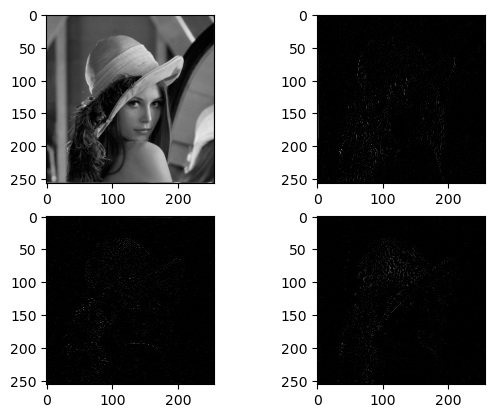

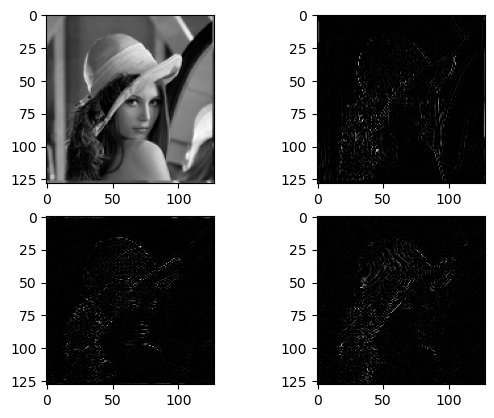

In [13]:
b = Db4()
img = normalize(np.asarray(Image.open('./lena512.jpg').convert('L')))
coeff = pywt.dwt2(img, 'db4')
CA,(c,d,e) = coeff
s,w1,w2,w3 = b.DWT2D(img, 1)
plt.subplot(2,2,1)
plt.imshow(s, cmap='gray', vmin=0, vmax=np.max(s))
plt.subplot(2,2,2)
plt.imshow(w1, cmap='gray', vmin=0, vmax=np.max(w1))
plt.subplot(2,2,3)
plt.imshow(w2, cmap='gray', vmin=0, vmax=np.max(w2))
plt.subplot(2,2,4)
plt.imshow(w3, cmap='gray', vmin=0, vmax=np.max(w3))
plt.show()


(s2, w21, w22, w23),w1,w2,w3 = b.DWT2D(img, 2)
plt.subplot(2,2,1)
plt.imshow(s2, cmap='gray', vmin=0, vmax=np.max(s2))
plt.subplot(2,2,2)
plt.imshow(w21, cmap='gray', vmin=0, vmax=np.max(w21))
plt.subplot(2,2,3)
plt.imshow(w22, cmap='gray', vmin=0, vmax=np.max(w22))
plt.subplot(2,2,4)
plt.imshow(w23, cmap='gray', vmin=0, vmax=np.max(w23))
plt.show()

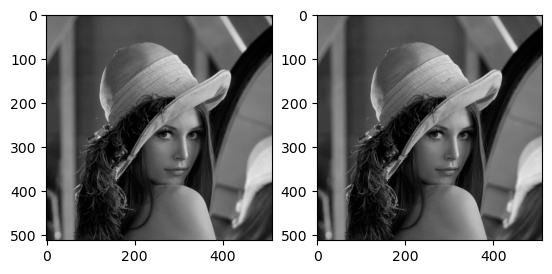

In [16]:
reconstructed = b.iDWT2D(b.DWT2D(img, 2), 2)
reconstructed = reconstructed
plt.subplot(1,2,1)
plt.imshow(reconstructed, cmap='gray', vmin=0, vmax=1)
plt.subplot(1,2,2)
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.show()
print(f"MSE of reconstructed image compared to original image: {MSE(img, reconstructed)}")
print(f"PSNR of reconstructed image compared to original image: {PSNR(img, reconstructed)}")

In [17]:
print(f"MSE of reconstructed image compared to original image: {MSE(img, reconstructed)}")
print(f"PSNR of reconstructed image compared to original image: {PSNR(img, reconstructed)}")

MSE of reconstructed image compared to original image: 2.8949572212497255e-26
PSNR of reconstructed image compared to original image: 255.383578494538


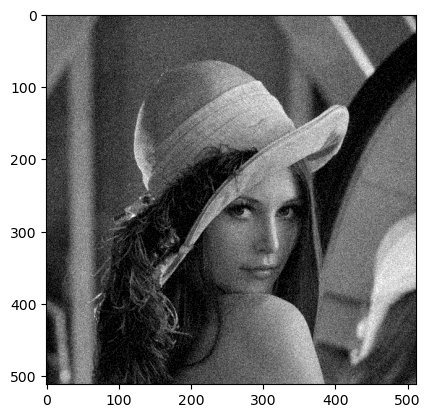

MSE of noisy image: 0.00490367077890969
MSE of noisy image: 23.09478695035803


In [18]:
noisy = gaussian_noise(img, 0.07)
plt.imshow(noisy, cmap='gray', vmin=0, vmax=1)
plt.show()
print(f"MSE of noisy image: {MSE(img, noisy)}")
print(f"MSE of noisy image: {PSNR(img, noisy)}")

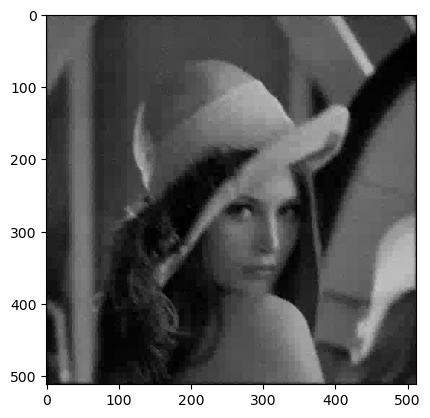

Haar hard thresholding: Best MSE of recovered image: 0.0054727031183619
Haar hard thresholding: Best PSNR of noisy image: 22.617981107016995
PSNR improved by 1.2581180328018249


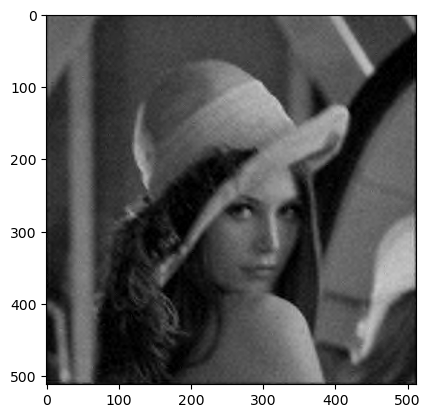

db4 hard thresholding: Best MSE of recovered image: 0.005090716600110983
db4 hard thresholding: Best PSNR of noisy image: 22.9322107943758
PSNR improved by 1.5723477201606286


In [30]:
threshold = 0
BestMSE = 10e10
BestResult = noisy
while (threshold < 0.7):
    result = a.denoising(noisy, threshold, 'hard', 4)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.01
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(f"Haar hard thresholding: Best MSE of recovered image: {BestMSE}")
print(f"Haar hard thresholding: Best PSNR of noisy image: {PSNR(img, BestResult)}")
print(f"PSNR improved by {PSNR(img, BestResult) - PSNR(img, noisy)}")

threshold = 0
BestMSE = 10e10
BestResult = noisy
while (threshold < 0.7):
    result = b.denoising(noisy, threshold, 'hard', 2)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.01
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(f"db4 hard thresholding: Best MSE of recovered image: {BestMSE}")
print(f"db4 hard thresholding: Best PSNR of noisy image: {PSNR(img, BestResult)}")
print(f"PSNR improved by {PSNR(img, BestResult) - PSNR(img, noisy)}")

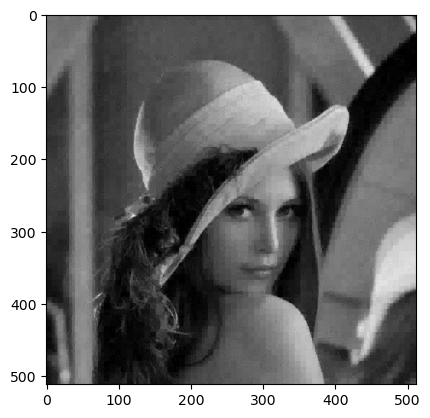

0.10999999999999999
29.51365229626361
Haar soft thresholding: Best MSE of recovered image: 0.0011184968629647666
Haar soft thresholding: Best PSNR of noisy image: 29.51365229626361
PSNR improved by 6.41886534590558


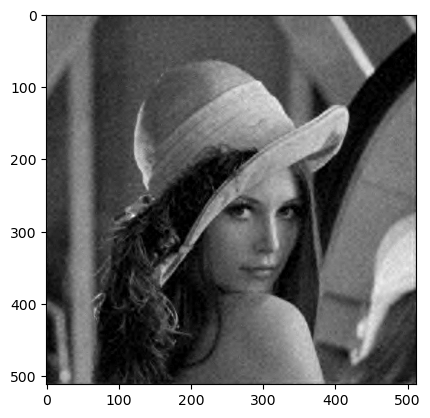

db4 soft thresholding: Best MSE of recovered image: 0.0009079460241891075
db4 soft thresholding: Best PSNR of noisy image: 30.419399687626022
PSNR improved by 7.324612737267991


In [20]:
threshold = 0
BestMSE = 10e10
BestResult = noisy
BestT = 0
while (threshold < 0.7):
    result = a.denoising(noisy, threshold, 'soft', 3)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
        BestT = threshold
    threshold += 0.01
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(BestT)
print(PSNR(img, BestResult))
print(f"Haar soft thresholding: Best MSE of recovered image: {BestMSE}")
print(f"Haar soft thresholding: Best PSNR of noisy image: {PSNR(img, BestResult)}")
print(f"PSNR improved by {PSNR(img, BestResult) - PSNR(img, noisy)}")

threshold = 0
BestMSE = 10e10
BestResult = noisy
while (threshold < 0.7):
    result = b.denoising(noisy, threshold, 'soft', 2)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.01
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(f"db4 soft thresholding: Best MSE of recovered image: {BestMSE}")
print(f"db4 soft thresholding: Best PSNR of noisy image: {PSNR(img, BestResult)}")
print(f"PSNR improved by {PSNR(img, BestResult) - PSNR(img, noisy)}")

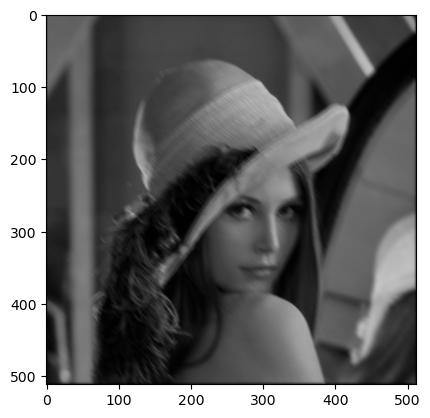

0.004820855028663674


In [22]:
size = 7
diagonal_kernel = np.zeros((size, size))
for i in range(size - 1):
    diagonal_kernel[i][i] = 1/(size * 2)
    diagonal_kernel[i][i + 1] = 1/(size * 2)

blurred = blur(img, diagonal_kernel)
plt.imshow(blurred, cmap='gray', vmin=0, vmax=1)
plt.show()
print(MSE(img, blurred))

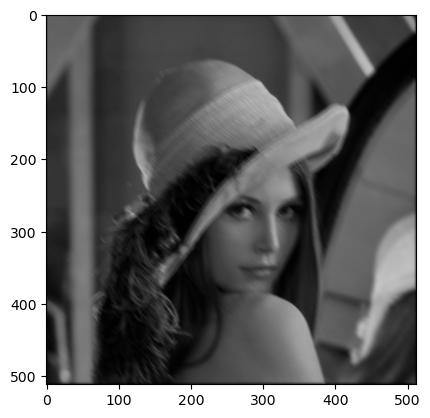

0.004820855028663742


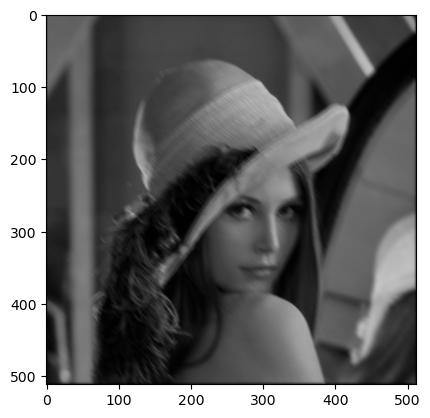

0.004820855028678469


In [29]:
threshold = 0
BestMSE = 10e10
BestResult = blurred
while (threshold < 1):
    result = a.denoising(blurred, threshold, 'hard', 4)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.05
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(BestMSE)

threshold = 0
BestMSE = 10e10
BestResult = blurred
while (threshold < 1):
    result = b.denoising(blurred, threshold, 'hard', 2)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.05
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(BestMSE)

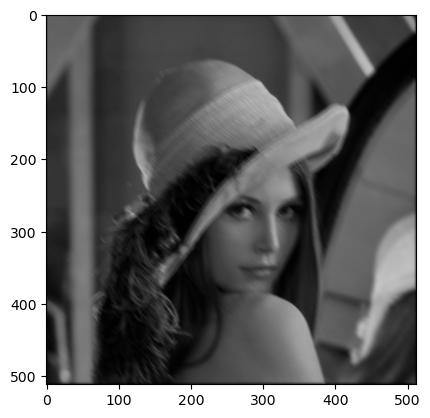

0.004820855028663742
23.168759282967116


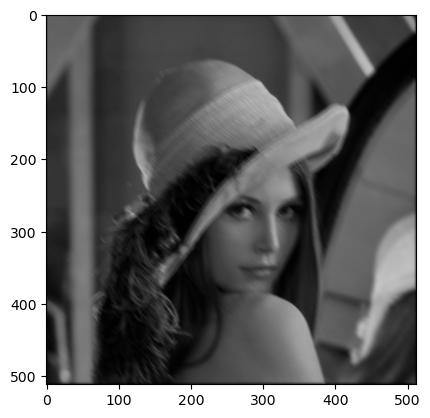

0.004820855028678469
23.168759282953847


In [23]:
threshold = 0
BestMSE = 10e10
BestResult = blurred
while (threshold < 1):
    result = a.denoising(blurred, threshold, 'soft', 4)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.05
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(BestMSE)
print(PSNR(img, BestResult))

threshold = 0
BestMSE = 10e10
BestResult = blurred
while (threshold < 1):
    result = b.denoising(blurred, threshold, 'soft', 2)
    currMSE = MSE(result, img)
    if currMSE < BestMSE:
        BestMSE = currMSE
        BestResult = result
    threshold += 0.05
plt.imshow(BestResult, cmap='gray', vmin=0, vmax=1)
plt.show()
print(BestMSE)
print(PSNR(img, BestResult))

Using pywt package to perform simple ISTA for image deblurring.

In [30]:
def wavelet_decomp(img, level, wavelet):
    coeffs = pywt.wavedec2(img, wavelet=wavelet, level=level)
    return coeffs

def wavelet_recon(coeffs, wavelet):
    return pywt.waverec2(coeffs, wavelet=wavelet)

def deblur_image(y, kernel,  level=2, lam=0.01, tau=0.3, max_iter=15):

    x_current = y.copy()
    for i in range(max_iter):
        Ax = convolve2d(x_current, kernel, mode='same', boundary='symm')
        grad_data = convolve2d(Ax - y, kernel[::-1, ::-1],
                             mode='same', boundary='symm')  # 对应A^T
    
        x_grad = x_current - tau * grad_data
    
        coeffs = wavelet_decomp(x_grad, level, "db4")
        for l in range(1, len(coeffs)):
            coeffs_l = list(coeffs[l])
            for c in range(3):  
                coeffs_l[c] = pywt.threshold(coeffs_l[c], tau * lam, mode='soft')
            coeffs[l] = tuple(coeffs_l)
    
        x_current = wavelet_recon(coeffs, "db4")

        loss = MSE(x_current, img)
        print(f"Iteration {i+1}/{max_iter}, Loss: {loss:.7f}")
        
    return x_current

Using self-implemented class to perform simple ISTA for image deblurring.

In [31]:
def deblur_image(blurred, kernel,  level=2, lam=0.01, step_size=0.4, max_iter=50):
    
    result = blurred.copy()
    db4 = Db4()
    
    for i in range(max_iter):
        Ax = signal.convolve2d(result, kernel, mode='same', boundary='symm')
        grad_data = signal.convolve2d(Ax - blurred, kernel[::-1, ::-1], mode='same', boundary='symm')

        x_grad = result - step_size * grad_data
    
        result = db4.denoising(x_grad, step_size * lam, mode = 'soft', levels = level)
    
        loss = MSE(img, result)
        print(f"Iteration {i+1}/{max_iter}, Loss: {loss:.7f}")
        
    return result

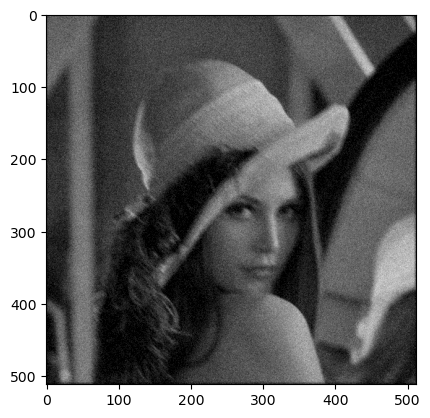

0.007337463132359017
21.344540678844673


In [32]:
img = normalize(np.asarray(Image.open('./lena512.jpg').convert('L')))
size = 7
diagonal_kernel = np.zeros((size, size))
for i in range(size - 1):
    diagonal_kernel[i][i] = 1/(size * 2)
    diagonal_kernel[i][i + 1] = 1/(size * 2)

blurred = blur(img, diagonal_kernel)
noisy = gaussian_noise(blurred, 0.05)
plt.imshow(noisy, cmap='gray', vmin=0, vmax=1)
plt.show()
print(MSE(img, noisy))
print(PSNR(img, noisy))

Iteration 1/50, Loss: 0.0053649
Iteration 2/50, Loss: 0.0042678
Iteration 3/50, Loss: 0.0036302
Iteration 4/50, Loss: 0.0032394
Iteration 5/50, Loss: 0.0029858
Iteration 6/50, Loss: 0.0028119
Iteration 7/50, Loss: 0.0026870
Iteration 8/50, Loss: 0.0025945
Iteration 9/50, Loss: 0.0025246
Iteration 10/50, Loss: 0.0024714
Iteration 11/50, Loss: 0.0024309
Iteration 12/50, Loss: 0.0024007
Iteration 13/50, Loss: 0.0023786
Iteration 14/50, Loss: 0.0023632
Iteration 15/50, Loss: 0.0023536
Iteration 16/50, Loss: 0.0023487
Iteration 17/50, Loss: 0.0023478
Iteration 18/50, Loss: 0.0023502
Iteration 19/50, Loss: 0.0023555
Iteration 20/50, Loss: 0.0023633
Iteration 21/50, Loss: 0.0023731
Iteration 22/50, Loss: 0.0023847
Iteration 23/50, Loss: 0.0023978
Iteration 24/50, Loss: 0.0024121
Iteration 25/50, Loss: 0.0024275
Iteration 26/50, Loss: 0.0024438
Iteration 27/50, Loss: 0.0024610
Iteration 28/50, Loss: 0.0024789
Iteration 29/50, Loss: 0.0024974
Iteration 30/50, Loss: 0.0025164
Iteration 31/50, Lo

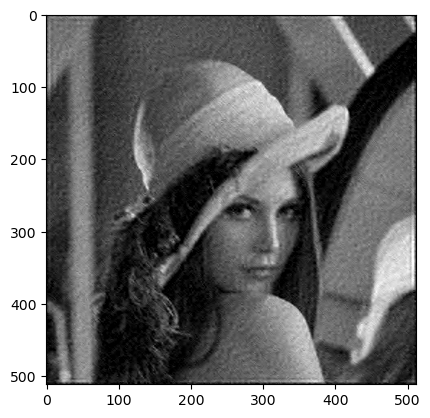

In [33]:
result = deblur_image(noisy, diagonal_kernel)
plt.imshow(result, cmap='gray', vmin=0, vmax=1)
print(f"MSE: {MSE(img, blurred)} -> {MSE(img, result)}, decreased by {(MSE(img, blurred) - MSE(img, result))/ MSE(img, blurred) * 100}%")
print(f"PSNR: {PSNR(img, blurred)}-> {PSNR(img, result)}, increased by {PSNR(img, result) - PSNR(img, blurred)} db")